In [1]:
import re
import pandas as pd

from aumann_ratio_decomposition import (
    AumannShapleyRatioDecomposer,
    SDConfig,
    SubgroupLooper,
)

In [10]:
# ============================================
# 1. Toy data: Product × age × impact
# ============================================
df_bef = [
    {"t": 0, "age": 10, "num": 10, "den": 100},
    {"t": 0, "age": 20, "num": 20, "den": 100},
]
df_aft = [
    {"t": 0, "age": 10, "num": 10, "den": 200},
    {"t": 0, "age": 20, "num": 100, "den": 250},
]

df_bef = pd.DataFrame(df_bef)
df_aft = pd.DataFrame(df_aft)

In [18]:
shapley_my_data = AumannShapleyRatioDecomposer(
        df_before=df_bef,
        df_after =df_aft,
        mode="group", keys=[], den_col="den", num_col="num"
    )

"""
shapley_my_data.plot_ratio_with_shapley_stacked(
    x_key="t",
    decompose_keys=["age"],
)
"""

ret = shapley_my_data.result()
ret

,t,age,den_bef,num_bef,den_aft,num_aft,den,num,_dummy,aumann_shapley
0,0,10,100,10,200,10,100,10,0,-0.066021
1,0,20,100,20,250,100,100,20,0,0.160466


[Loop 0] remaining=2, alpha=0.100
  -> picked 2 rows (100.00% of total target, 0.00% remain), condition: Dataset
  -> remain ratio 0.00% below threshold (10.00%). stop.
   rank     rule  support       sum
0     1  Dataset        2  0.094444


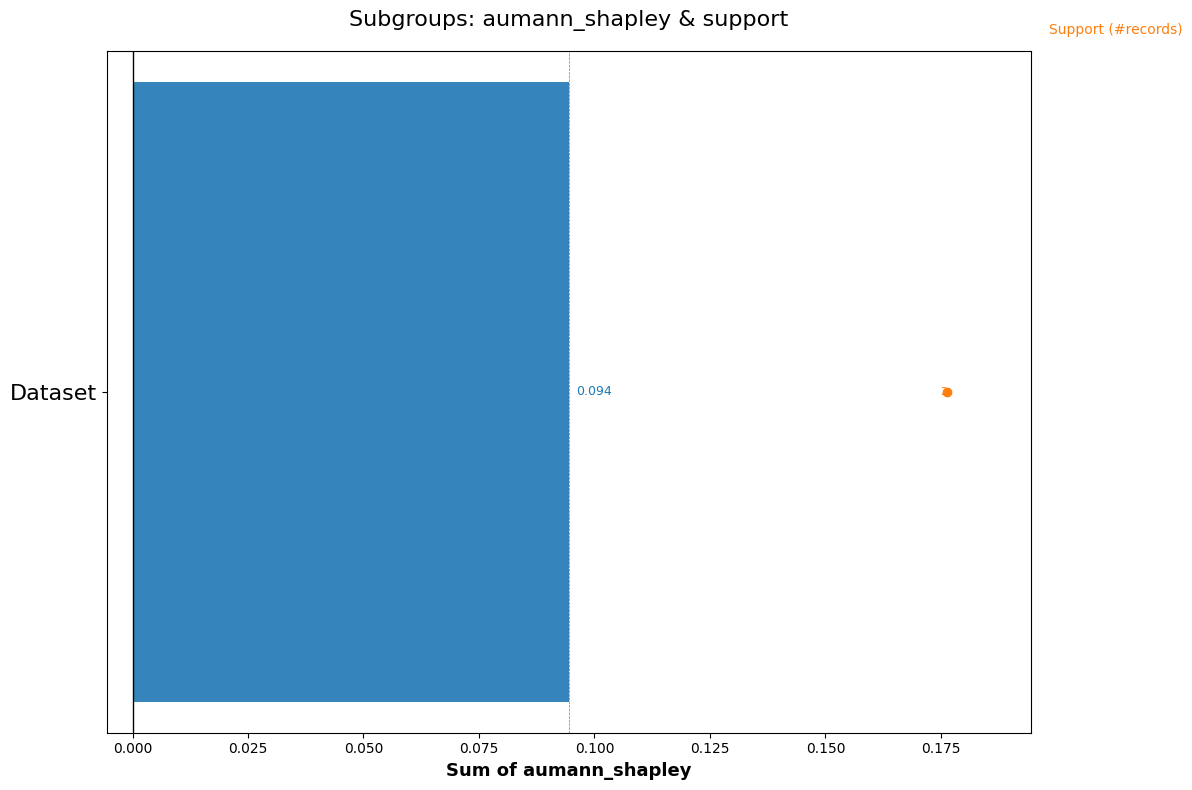

In [17]:

cfg = SDConfig(
    target_col='aumann_shapley',
    use_abs_std_qf_numeric=True,  # Use absolute StandardQFNumeric scoring
    depth=3,                      # Max rule depth / number of conditions
    alpha_start=0.1,              # Beam search weighting parameter start
    alpha_decay=0.3,              # Weight decay across depths
    min_support=1000,             # Minimum subgroup size
    ratio_threshold=0.1,
    max_loops=None,
    intervals_only=False,
    nbins=5,                      # Discretization bins for numeric attributes
)

runner = SubgroupLooper(ret, cfg)
df_summary = runner.run()
print(df_summary)

# Plot subgroup results for interpretation
runner.plot(df_summary, wrap_width=40, fig_width=12, font_size=16)
